In [1]:
# Example plots ADV data Hybrid Dune Campaign

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [ ]:
# Open ADV data
nc_raw = r'O:\HybridDune experiment\data ADV, OBS\raw NetCDF\ADV S3ADV1 raw data - period 2 20mins.nc'
ds_ADV = xr.open_dataset(nc_raw)
ds_ADV 

<xarray.Dataset> Size: 1GB
Dimensions:      (t: 1161, N: 9600, t_theta: 2, t_zb: 6, t_zi: 2)
Coordinates:
  * t            (t) datetime64[ns] 9kB 2024-12-31T11:00:00 ... 2025-01-16T13...
  * N            (N) float64 77kB 0.0 0.125 0.25 ... 1.2e+03 1.2e+03 1.2e+03
  * t_theta      (t_theta) datetime64[ns] 16B 2024-12-31T10:30:00 2025-01-06T...
  * t_zb         (t_zb) datetime64[ns] 48B 2024-12-31T10:30:00 ... 2025-01-12...
  * t_zi         (t_zi) datetime64[ns] 16B 2024-12-31T10:30:00 2025-01-06T12:...
Data variables: (12/47)
    sf           float64 8B ...
    p            (t, N) float64 89MB ...
    u            (t, N) float64 89MB ...
    v            (t, N) float64 89MB ...
    w            (t, N) float64 89MB ...
    anl1         (t, N) float32 45MB ...
    ...           ...
    theta_ADV    (t_theta) float64 16B ...
    zb           (t_zb) float64 48B ...
    zi           (t_zi) float64 16B ...
    zi_OBShigh   (t_zi) float64 16B ...
    zi_OBSlow    (t_zi) float64 16B ...
    zi_p         (t_zi) float64 16B ...
Attributes: (12/13)
    Conventions:               CF-1.6
    title:                     S3ADV1 raw data - period 2
    instrument:                Nortek Vector
    instrument serial number:  VEC14808
    connected OBS type:        Cambell OBS3+
    time zone:                 UTC+1
    ...                        ...
    summary:                   hybrid-Dune field campaign
    contact person:            Daan Poppema
    emailadres:                d.w.poppema@tudelft.nl
    construction datetime:     20-Oct-2025 (18:26:44)
    version:                   v1
    version comments:          constructed with xarray

In [ ]:
nc_QC  = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\QC\Deployment period 2\Pressure sensor refP1 RBR3 p_air - period 2.nc'
ds_RBR = xr.open_dataset(nc_QC)
ds_RBR

<xarray.Dataset> Size: 297MB
Dimensions:      (t: 12384001)
Coordinates:
  * t            (t) datetime64[ns] 99MB 2024-12-31T11:00:00 ... 2025-01-18T0...
Data variables:
    p_abs        (t) float64 99MB ...
    x_RD         float64 8B ...
    y_RD         float64 8B ...
    x_local      float64 8B ...
    y_local      float64 8B ...
    sf           int64 8B ...
    t_installed  datetime64[ns] 8B ...
    t_removed    datetime64[ns] 8B ...
    p_air        (t) float64 99MB ...
Attributes: (12/16)
    Conventions:               CF-1.6
    name:                      Pressure sensor refP1 RBR, period 2
    instrument:                Pressure sensor refP1 RBR3
    instrument type:           Ruskin RBR Solo
    instrument serial number:  202440
    epsg:                      28992
    ...                        ...
    contact person:            Daan Poppema
    emailadres:                d.w.poppema@tudelft.nl
    construction datetime:     09-Sep-2025 17:18:03
    version:                   v1
    comment_1:                 constructed with xarray
    url of online dataset:     ADD LATER

In [74]:
p_ADV = (ds_ADV.p - 98378) / 100      # convert to cm
p_RBR = (ds_RBR.p_air - 98378) / 100  # convert to cm

p_ADV_cal = p_ADV.sel(t=slice(np.datetime64('2025-01-04T00:00'), np.datetime64('2025-01-04T00:59')))
p_RBR_cal = p_RBR.sel(t=slice(np.datetime64('2025-01-04T00:00'), np.datetime64('2025-01-04T01:00')))

# Build 2D time grid: t (datetime64) + N (seconds as timedelta64)
time2d = p_ADV['t'] + p_ADV['N'].astype('timedelta64[s]')

# Flatten to 1D with real time coord
p_1d    = p_ADV.stack(time=('t', 'N'))
time_1d = time2d.stack(time=('t', 'N'))

# repeat for cal section
time2d      = p_ADV_cal['t'] + p_ADV_cal['N'].astype('timedelta64[s]')
p_1d_cal    = p_ADV_cal.stack(time=('t', 'N'))
time_1d_cal = time2d.stack(time=('t', 'N'))

(0.0, 75.0)

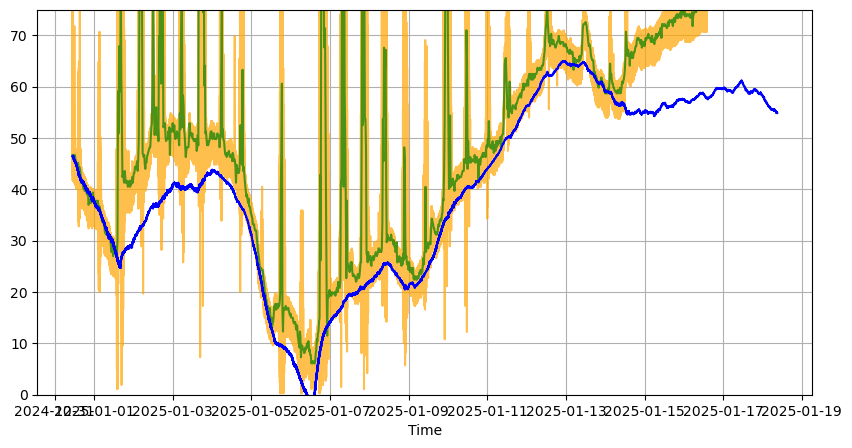

In [82]:
# compare pressure from RBR with pressure from ADV
plt.figure(figsize=(10,5))
#plt.plot( p_ADV, label='S3ADV2', color='blue', alpha=0.7)
plt.plot(time_1d, p_1d, label='S3ADV1', color='orange', alpha=0.7)
plt.plot(p_ADV.t, p_ADV[:,0], label='ADV block mean', color='green', alpha=0.7)
plt.plot(p_RBR.t[::10], p_RBR[::10], label='ref.P1', color='blue')

plt.xlabel('Time')
plt.grid()
plt.ylim(0 , 75 )
#plt.xlim(np.datetime64('2025-01-03T00:00'), np.datetime64('2025-01-05T23:59'))

# Conclusion: follow each other reasonably well, but ADV tends to give higher pressures


(-10.0, 10.0)

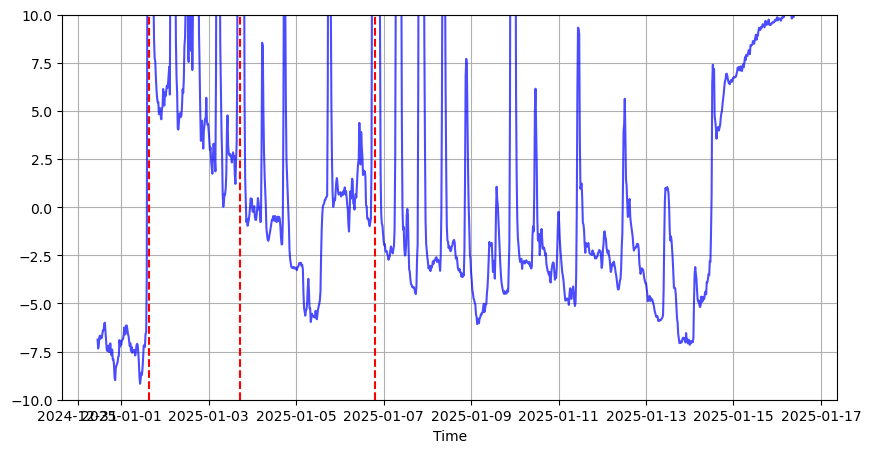

In [ ]:
# compare pressure from RBR with pressure from ADV
dp = p_ADV.mean(dim='N') - p_RBR
new_offset = 0#7

plt.figure(figsize=(10,5))
plt.plot(dp.t, dp-new_offset, label='S3ADV2', color='blue', alpha=0.7)

# plot vertical lines at 1 jan 2025 15:00; 3 jan 17:00 and 6 jan 19:00
plt.axvline(x=np.datetime64('2025-01-01T15:00'), color='red', linestyle='--') # 0 and 13 cm
plt.axvline(x=np.datetime64('2025-01-03T17:00'), color='red', linestyle='--') # 8 cm
plt.axvline(x=np.datetime64('2025-01-06T19:00'), color='red', linestyle='--') # 7 cm

plt.xlabel('Time')
plt.grid()
plt.ylim(-10 , 20 )

# xlim 3 to5 jan
#plt.xlim(np.datetime64('2025-01-03T00:00'), np.datetime64('2025-01-05T23:59'))

# Conclusion: ADV has an offset that changes over time. For the first storm 0 cm before the storm, 13 cm afterwards. For the second and third storm 8 and 7 cm respectively. Avg about 7 cm too high. 
# Choose a calibration period tactically to minimize the avg difference between ref pressure and adv. From plotting ADV 7 cm lower, period of 4 jan 2025 00:00 to 01:00 seems good


97695

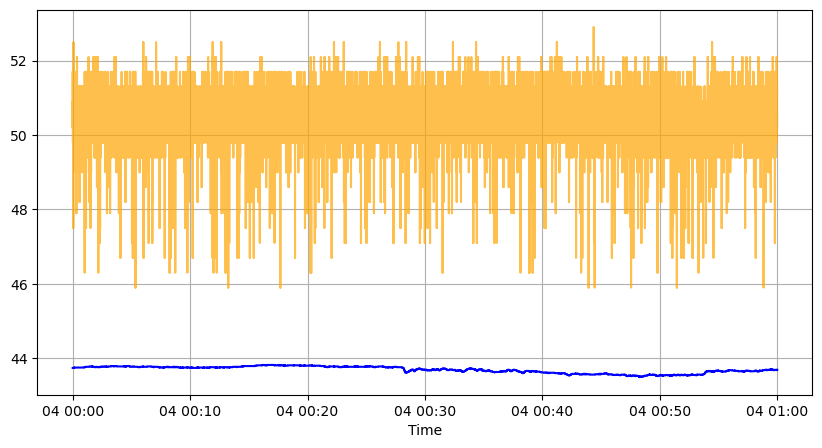

In [ ]:
# compare pressure from RBR with pressure from ADV, calibration period
plt.figure(figsize=(10,5))
plt.plot(time_1d_cal, p_1d_cal, label='S3ADV1', color='orange', alpha=0.7)
plt.plot(p_RBR_cal.t, p_RBR_cal, label='RBR6 S3P3', color='blue')

plt.xlabel('Time')
plt.grid()

# print mean difference between the two
mean_diff = (p_1d_cal.values.mean() - p_RBR_cal.values.mean())
mean_diff*100

# Conclusion: lower the old offset of 98378 with 683 Pa, i.e. use 97695 Pa as new offset